# Tugas - HDBSCAN pada Dataset Nyata

**Nama:** Radit Firansah  
**NIM:** 244107020196

Dataset: **Iris** dan **Digits** dari `sklearn.datasets`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, homogeneity_score, completeness_score

%matplotlib inline

In [2]:
def ringkas(X, labels, name):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f'=== {name} ===')
    print(f'Jumlah cluster: {n_clusters}')
    print(f'Jumlah noise  : {n_noise}')
    if n_clusters > 1:
        print(f'Silhouette    : {silhouette_score(X, labels):.3f}')
        print(f'Davies-Bouldin: {davies_bouldin_score(X, labels):.3f}')
    return n_clusters, n_noise

## 1. Iris Dataset

In [3]:
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)

hdb = hdbscan.HDBSCAN(min_cluster_size=5).fit(X_iris)
ringkas(X_iris, hdb.labels_, 'Iris')

print(f'ARI (vs label asli): {adjusted_rand_score(iris.target, hdb.labels_):.3f}')
print(f'Homogeneity        : {homogeneity_score(iris.target, hdb.labels_):.3f}')
print(f'Completeness       : {completeness_score(iris.target, hdb.labels_):.3f}')

=== Iris ===
Jumlah cluster: 2
Jumlah noise  : 2
Silhouette    : 0.489
Davies-Bouldin: 0.535
ARI (vs label asli): 0.539
Homogeneity        : 0.554
Completeness       : 0.873


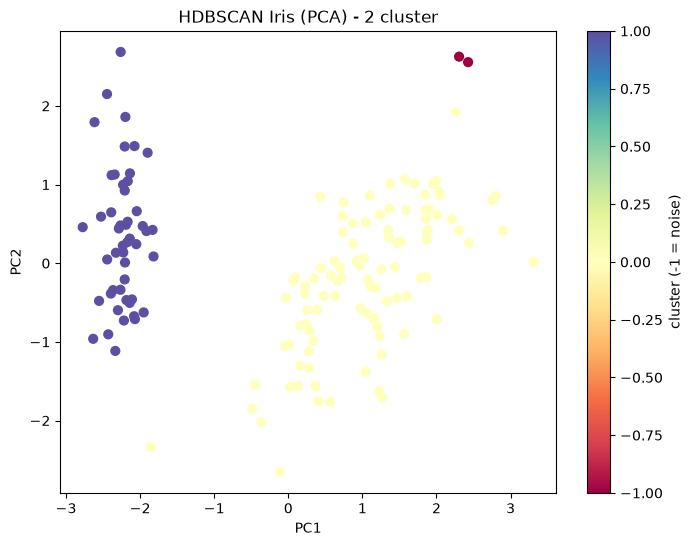

In [4]:
X_pca = PCA(n_components=2, random_state=0).fit_transform(X_iris)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hdb.labels_, cmap='Spectral', s=40)
plt.title(f'HDBSCAN Iris (PCA) - {len(set(hdb.labels_)) - (1 if -1 in hdb.labels_ else 0)} cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(sc, label='cluster (-1 = noise)')
plt.show()

## 2. Digits Dataset

In [5]:
digits = load_digits()
X_digits = StandardScaler().fit_transform(digits.data)

hdb_d = hdbscan.HDBSCAN(min_cluster_size=15).fit(X_digits)
ringkas(X_digits, hdb_d.labels_, 'Digits')

print(f'ARI (vs label asli): {adjusted_rand_score(digits.target, hdb_d.labels_):.3f}')
print(f'Homogeneity        : {homogeneity_score(digits.target, hdb_d.labels_):.3f}')
print(f'Completeness       : {completeness_score(digits.target, hdb_d.labels_):.3f}')

=== Digits ===
Jumlah cluster: 7
Jumlah noise  : 1218
Silhouette    : -0.076
Davies-Bouldin: 2.227
ARI (vs label asli): 0.107
Homogeneity        : 0.348
Completeness       : 0.669


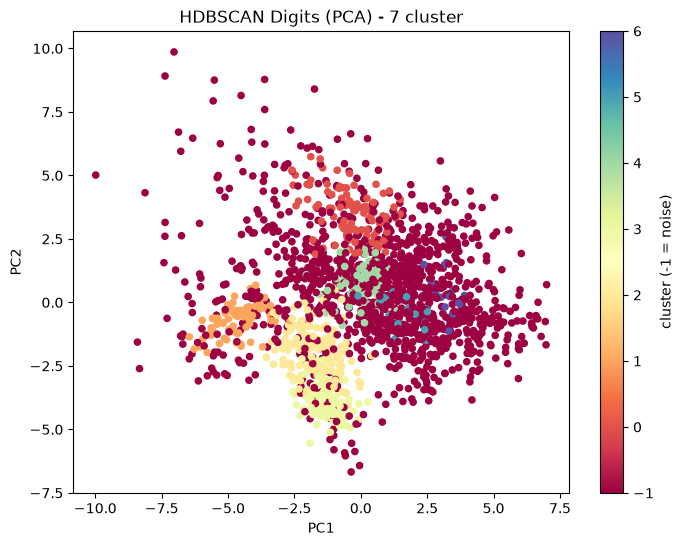

In [6]:
X_pca_d = PCA(n_components=2, random_state=0).fit_transform(X_digits)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca_d[:, 0], X_pca_d[:, 1], c=hdb_d.labels_, cmap='Spectral', s=20)
plt.title(f'HDBSCAN Digits (PCA) - {len(set(hdb_d.labels_)) - (1 if -1 in hdb_d.labels_ else 0)} cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(sc, label='cluster (-1 = noise)')
plt.show()

## 3. Analisis

- **Iris**: HDBSCAN menemukan 2 cluster. Struktur densitas pada ruang 4 dimensi menggabungkan `versicolor` dan `virginica` (keduanya memang saling tumpang tindih), sementara `setosa` terpisah jelas. Karena `setosa` sangat terpisah, ARI cukup tinggi namun tidak sempurna.
- **Digits**: HDBSCAN menghasilkan banyak cluster dan noise yang besar. Data digit berdimensi 64 dengan struktur sangat kompleks sehingga berbasis densitas sulit memisahkan tiap angka secara bersih.
- **Kesimpulan**: HDBSCAN tidak selalu menghasilkan cluster sejumlah label asli. Hasilnya bergantung pada struktur kepadatan data; untuk data yang tumpang tindih seperti Iris, jumlah cluster < jumlah kelas asli adalah hal yang wajar.